In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All imports successful!")
print("Today we learn Decision Trees and Random Forest")

All imports successful!
Today we learn Decision Trees and Random Forest


In [2]:
np.random.seed(42)

data = {
    # Study habits
    'attendance_pct':   [90, 85, 60, 45, 78, 30, 92, 55, 70, 88,
                         35, 65, 80, 25, 95, 50, 72, 40, 82, 68,
                         28, 75, 58, 91, 48, 83, 37, 62, 77, 44],

    # Academic performance
    'cgpa':             [8.5, 7.8, 6.2, 5.1, 7.0, 4.2, 8.8, 5.8, 6.8, 8.0,
                         4.5, 6.5, 7.5, 3.8, 9.0, 5.5, 7.2, 4.8, 7.8, 6.5,
                         4.0, 7.3, 6.0, 8.7, 5.3, 7.9, 4.3, 6.3, 7.1, 5.0],

    # Assignment completion (out of 10)
    'assignments_done': [9, 8, 6, 4, 7, 2, 10, 5, 7, 9,
                         3, 6, 8, 2, 10, 5, 7, 4, 8, 6,
                         2, 7, 5, 9, 4, 8, 3, 6, 7, 4],

    # Active backlogs
    'backlogs':         [0, 0, 2, 4, 1, 5, 0, 3, 1, 0,
                         4, 2, 0, 6, 0, 3, 1, 4, 0, 2,
                         5, 1, 2, 0, 3, 0, 5, 2, 1, 3],

    # Participation in college activities (1-10)
    'participation':    [8, 7, 5, 3, 6, 2, 9, 4, 6, 8,
                         2, 5, 7, 1, 9, 4, 6, 3, 7, 5,
                         2, 6, 4, 8, 3, 7, 2, 5, 6, 3],

    # 1 = dropout risk, 0 = safe
    'dropout_risk':     [0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
                         1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
                         1, 0, 1, 0, 1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

print("Dataset Created!")
print(f"total students: {len(df)}")
print(f"At dropout risk: {df['dropout_risk']. sum()}")
print(f"safe students: {(df['dropout_risk'] == 0). sum()}")
print()
print(df.head(10))

Dataset Created!
total students: 30
At dropout risk: 16
safe students: 14

   attendance_pct  cgpa  assignments_done  backlogs  participation  \
0              90   8.5                 9         0              8   
1              85   7.8                 8         0              7   
2              60   6.2                 6         2              5   
3              45   5.1                 4         4              3   
4              78   7.0                 7         1              6   
5              30   4.2                 2         5              2   
6              92   8.8                10         0              9   
7              55   5.8                 5         3              4   
8              70   6.8                 7         1              6   
9              88   8.0                 9         0              8   

   dropout_risk  
0             0  
1             0  
2             1  
3             1  
4             0  
5             1  
6             0  
7         

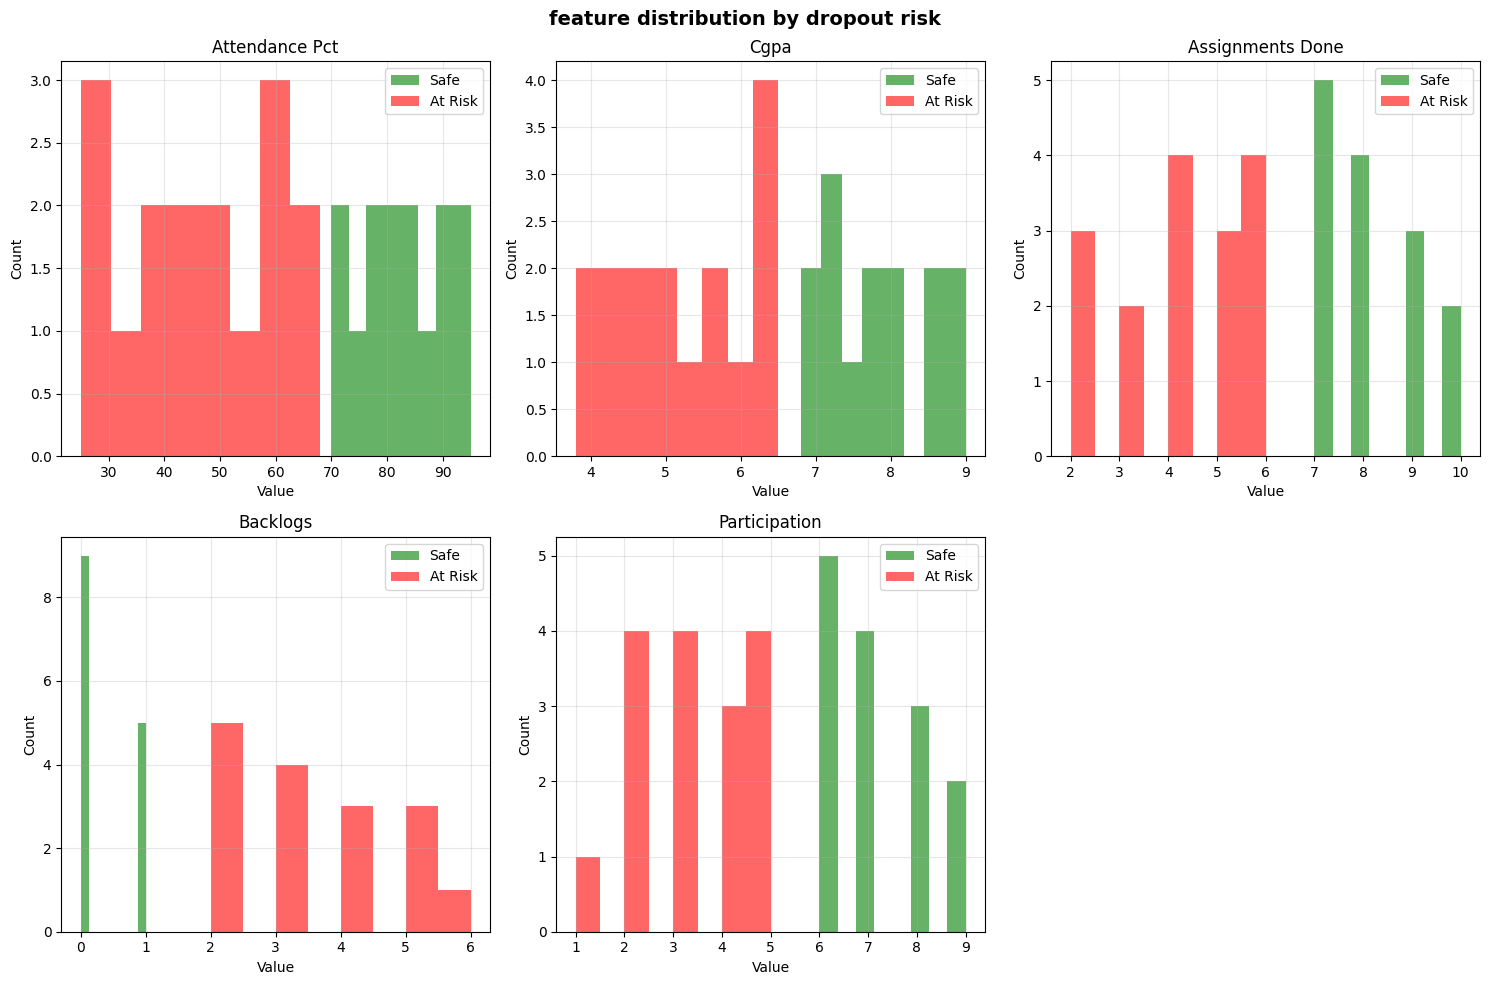

Study the graphs!
Green (safe) should be on the RIGHT for good features
Red (at risk) should be on the LEFT for good features
For backlogs it is reversed — more backlogs = more risk


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('feature distribution by dropout risk',
             fontsize=14, fontweight='bold')

features = ['attendance_pct', 'cgpa', 
            'assignments_done', 'backlogs', 'participation']

colors_safe = 'green'
colors_atrisk = 'red'

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    ax = axes[row][col]

    safe   = df[df['dropout_risk'] == 0][feature]
    atrisk = df[df['dropout_risk'] == 1][feature]

    ax.hist(safe,   bins=8, alpha=0.6,
            color=colors_safe,   label='Safe')
    ax.hist(atrisk, bins=8, alpha=0.6,
            color=colors_atrisk, label='At Risk')

    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

    axes[1][2].set_visible(False)

plt.tight_layout()
plt.show()

print("Study the graphs!")
print("Green (safe) should be on the RIGHT for good features")
print("Red (at risk) should be on the LEFT for good features")
print("For backlogs it is reversed — more backlogs = more risk")

In [4]:
X = df[['attendance_pct', 'cgpa',
        'assignments_done', 'backlogs', 'participation']]
y = df['dropout_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print(f"Training students: {len(X_train)}")
print(f"Testing students:  {len(X_test)}")
print()

tree_model = DecisionTreeClassifier(
    max_depth = 4,
    random_state = 42
)

tree_model.fit(X_train, y_train)

print("Decision Tree trained!")
print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves: {tree_model.get_n_leaves()}")

Training students: 22
Testing students:  8

Decision Tree trained!
Tree depth: 1
Number of leaves: 2


In [5]:
feature_names = ['attendance_pct', 'cgpa',
                 'assignments_done', 'backlogs', 'participation']

tree_text = export_text(tree_model,
                        feature_names=feature_names)
print("THE DECISION TREE:")
print("==================")
print(tree_text)

print()
print("How to read this:")
print("  attendance_pct <= 67.5 means:")
print("  'Is attendance less than or equal to 67.5%?'")
print("  YES → go left branch")
print("  NO  → go right branch")
print("  class: 1 means DROPOUT RISK")
print("  class: 0 means SAFE")

THE DECISION TREE:
|--- backlogs <= 1.50
|   |--- class: 0
|--- backlogs >  1.50
|   |--- class: 1


How to read this:
  attendance_pct <= 67.5 means:
  'Is attendance less than or equal to 67.5%?'
  YES → go left branch
  NO  → go right branch
  class: 1 means DROPOUT RISK
  class: 0 means SAFE


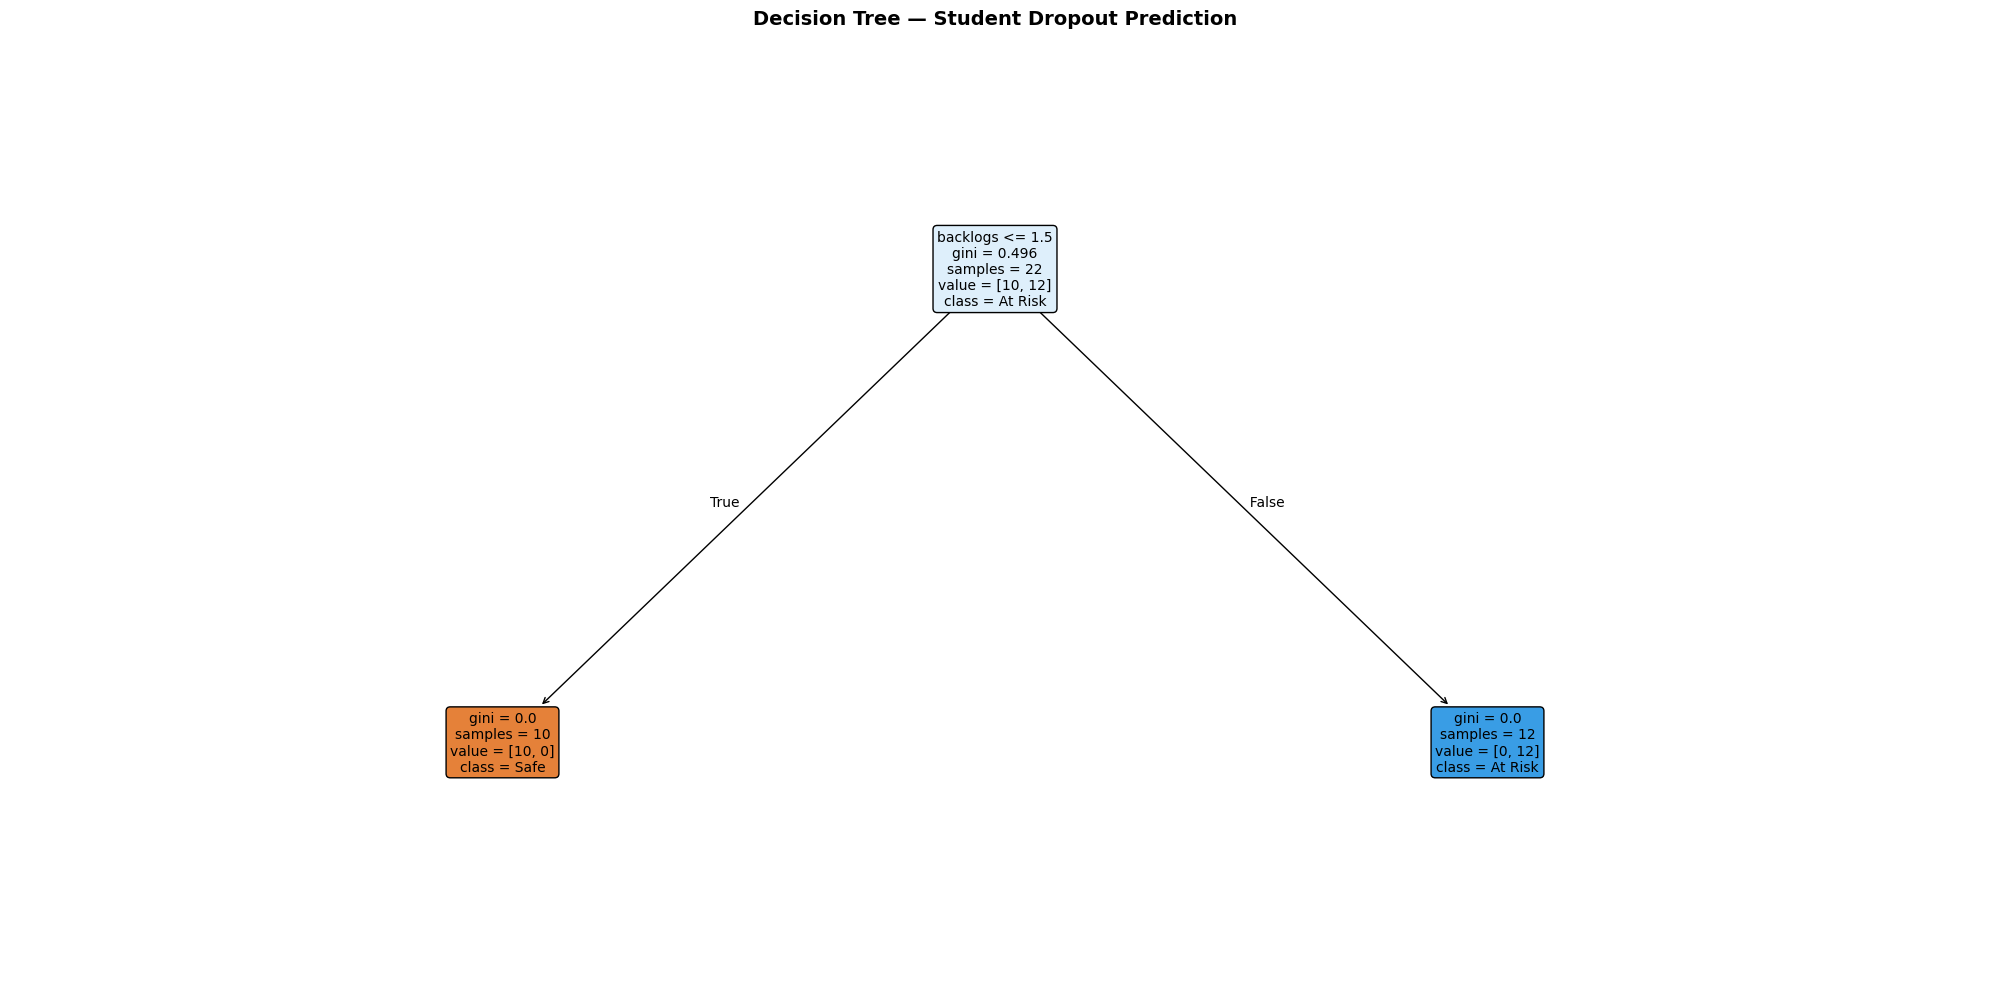

Blue boxes = Safe students
Orange boxes = At Risk students
Darker color = more confident prediction


In [6]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Safe', 'At Risk'],
    filled=True,          # color the boxes
    rounded=True,         # rounded corners
    fontsize=10
)

plt.title("Decision Tree — Student Dropout Prediction",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Blue boxes = Safe students")
print("Orange boxes = At Risk students")
print("Darker color = more confident prediction")

In [7]:
tree_predictions = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)
print(f"Decision Tree Accuracy: {tree_accuracy * 100:.1f}%")
print()

cm = confusion_matrix(y_test, tree_predictions)
print("Confusion Matrix:")
print(cm)
print()
print(f"Correctly identified SAFE students:    {cm[0][0]}")
print(f"Incorrectly flagged as AT RISK:        {cm[0][1]}")
print(f"Missed AT RISK students (dangerous!):  {cm[1][0]}")
print(f"Correctly identified AT RISK students: {cm[1][1]}")
print()

print(classification_report(y_test, tree_predictions,
      target_names=['Safe', 'At Risk']))

Decision Tree Accuracy: 100.0%

Confusion Matrix:
[[4 0]
 [0 4]]

Correctly identified SAFE students:    4
Incorrectly flagged as AT RISK:        0
Missed AT RISK students (dangerous!):  0
Correctly identified AT RISK students: 4

              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00         4
     At Risk       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



Feature Importance (what matters most):
1. backlogs             100.0%
2. participation        0.0%
3. assignments_done     0.0%
4. cgpa                 0.0%
5. attendance_pct       0.0%


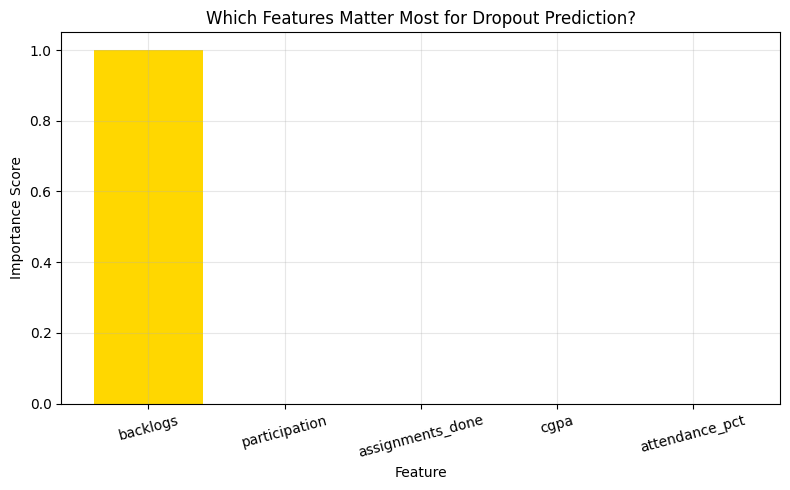

In [8]:
importances = tree_model.feature_importances_

indices = np.argsort(importances)[::-1]

print("Feature Importance (what matters most):")
print("=" * 40)
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]:20} {importances[idx]*100:.1f}%")

plt.figure(figsize=(8, 5))
plt.bar(
    range(len(feature_names)),
    importances[indices],
    color=['gold', 'silver', '#cd7f32', 'steelblue', 'lightcoral']
)
plt.xticks(
    range(len(feature_names)),
    [feature_names[i] for i in indices],
    rotation=15
)
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Which Features Matter Most for Dropout Prediction?')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
overfit_tree = DecisionTreeClassifier(
    max_depth=None,   # no limit
    random_state=42
)
overfit_tree.fit(X_train, y_train)

train_pred = overfit_tree.predict(X_train)
test_pred  = overfit_tree.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

print("OVERFITTING DEMONSTRATION:")
print(f"  Training accuracy: {train_acc*100:.1f}%")
print(f"  Testing accuracy:  {test_acc*100:.1f}%")
print()
print("See the gap?")
print("Perfect on training data but worse on test data")
print("The model memorized instead of learning patterns")
print()
print("This is like a student who memorizes answers")
print("but cannot solve new questions in the exam")

OVERFITTING DEMONSTRATION:
  Training accuracy: 100.0%
  Testing accuracy:  100.0%

See the gap?
Perfect on training data but worse on test data
The model memorized instead of learning patterns

This is like a student who memorizes answers
but cannot solve new questions in the exam


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,  # 100 trees
    max_depth=4,       # each tree limited to depth 4
    random_state=42
)

rf_model.fit(X_train, y_train)

# Compare all models
print("MODEL COMPARISON:")
print("=" * 50)

models = {
    "Single Tree (depth=4)":     tree_model,
    "Overfit Tree (no limit)":   overfit_tree,
    "Random Forest (100 trees)": rf_model,
}

for name, mdl in models.items():
    train_a = accuracy_score(y_train, mdl.predict(X_train))
    test_a  = accuracy_score(y_test,  mdl.predict(X_test))
    gap     = train_a - test_a
    print(f"\n{name}")
    print(f"  Train: {train_a*100:.1f}% | Test: {test_a*100:.1f}% | Gap: {gap*100:.1f}%")

print()
print("Random Forest should have:")
print("  Smallest gap between train and test")
print("  Best test accuracy overall")

MODEL COMPARISON:

Single Tree (depth=4)
  Train: 100.0% | Test: 100.0% | Gap: 0.0%

Overfit Tree (no limit)
  Train: 100.0% | Test: 100.0% | Gap: 0.0%

Random Forest (100 trees)
  Train: 100.0% | Test: 100.0% | Gap: 0.0%

Random Forest should have:
  Smallest gap between train and test
  Best test accuracy overall


Random Forest Feature Importance:
1. backlogs             23.0% ███████████
2. attendance_pct       22.0% ███████████
3. participation        21.0% ██████████
4. cgpa                 19.0% █████████
5. assignments_done     15.0% ███████


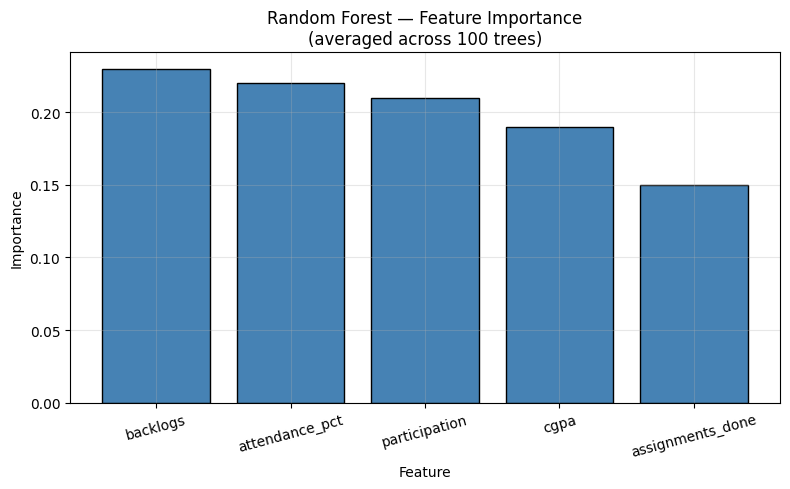

In [11]:
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

print("Random Forest Feature Importance:")
print("=" * 40)
for i, idx in enumerate(rf_indices):
    bar = "█" * int(rf_importances[idx] * 50)
    print(f"{i+1}. {feature_names[idx]:20} "
          f"{rf_importances[idx]*100:.1f}% {bar}")

plt.figure(figsize=(8, 5))
plt.bar(
    range(len(feature_names)),
    rf_importances[rf_indices],
    color='steelblue',
    edgecolor='black'
)
plt.xticks(
    range(len(feature_names)),
    [feature_names[i] for i in rf_indices],
    rotation=15
)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest — Feature Importance\n'
          '(averaged across 100 trees)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
def predict_dropout_risk(attendance, cgpa,
                         assignments, backlogs, participation):

    student = np.array([[attendance, cgpa,
                         assignments, backlogs, participation]])

    prediction   = rf_model.predict(student)[0]
    probability  = rf_model.predict_proba(student)[0]

    risk_level = "🔴 HIGH RISK" if prediction == 1 else "🟢 SAFE"
    risk_prob  = probability[1] * 100
    safe_prob  = probability[0] * 100

    print(f"Attendance:    {attendance}%")
    print(f"CGPA:          {cgpa}")
    print(f"Assignments:   {assignments}/10")
    print(f"Backlogs:      {backlogs}")
    print(f"Participation: {participation}/10")
    print(f"Status:        {risk_level}")
    print(f"Risk prob:     {risk_prob:.1f}%")
    print(f"Safe prob:     {safe_prob:.1f}%")

    if prediction == 1:
        print("⚠️  Recommend: Immediate counselling")
    else:
        print("✅ Student appears on track")
    print("-" * 40)

print("STUDENT PREDICTIONS")
print("=" * 40)

print("\nStudent 1 — Clearly safe:")
predict_dropout_risk(92, 8.5, 9, 0, 8)

print("\nStudent 2 — Clearly at risk:")
predict_dropout_risk(35, 4.2, 2, 5, 2)

print("\nStudent 3 — Borderline:")
predict_dropout_risk(65, 6.0, 5, 2, 5)

print("\nStudent 4 — Good academics, low attendance:")
predict_dropout_risk(45, 8.0, 8, 0, 7)

STUDENT PREDICTIONS

Student 1 — Clearly safe:


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Attendance:    92%
CGPA:          8.5
Assignments:   9/10
Backlogs:      0
Participation: 8/10
Status:        🟢 SAFE
Risk prob:     0.0%
Safe prob:     100.0%
✅ Student appears on track
----------------------------------------

Student 2 — Clearly at risk:
Attendance:    35%
CGPA:          4.2
Assignments:   2/10
Backlogs:      5
Participation: 2/10
Status:        🔴 HIGH RISK
Risk prob:     100.0%
Safe prob:     0.0%
⚠️  Recommend: Immediate counselling
----------------------------------------

Student 3 — Borderline:
Attendance:    65%
CGPA:          6.0
Assignments:   5/10
Backlogs:      2
Participation: 5/10
Status:        🔴 HIGH RISK
Risk prob:     100.0%
Safe prob:     0.0%
⚠️  Recommend: Immediate counselling
----------------------------------------

Student 4 — Good academics, low attendance:
Attendance:    45%
CGPA:          8.0
Assignments:   8/10
Backlogs:      0
Participation: 7/10
Status:        🟢 SAFE
Risk prob:     22.0%
Safe prob:     78.0%
✅ Student appears on track
---

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
